Name: Shubha Ghimire
ID: 2430050
Worksheet 4

In [9]:
# ============================================
# Worksheet - 4: Devnagari Handwritten Digit Classification
# Building Fully Connected Neural Network with Keras
# ============================================

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [10]:
import zipfile
import os
from tqdm import tqdm

def extract_zip_with_progress(zip_path, extract_to='/content'):
    """Extract ZIP file with a progress bar."""
    os.makedirs(extract_to, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        members = zip_ref.infolist()
        total = len(members)

        print(f"📦 Found {total} files | Size: {sum(m.file_size for m in members) / 1e6:.1f} MB")

        for member in tqdm(members, desc="Extracting", unit="file"):
            zip_ref.extract(member, extract_to)

    print(f"Done! Files saved to: {extract_to}")

# Usage
extract_zip_with_progress('/content/drive/MyDrive/Level 6 AI/week4/Copy of Copy of devnagari digit.zip', '/content/output')

📦 Found 20000 files | Size: 12.0 MB


Extracting: 100%|██████████| 20000/20000 [00:03<00:00, 5503.39file/s]

✅ Done! Files saved to: /content/output


In [11]:
# ============================================
# TASK 1: Data Preparation
# ============================================

# Define dataset paths
train_dir = "/content/output/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/output/DevanagariHandwrittenDigitDataset/Test"

img_height, img_width = 28, 28

def load_images_from_folder(folder):
    """Load images from folder structure using PIL."""
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    print(f"Found classes: {class_names}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        if not os.path.isdir(class_path):
            continue

        file_count = 0
        for filename in os.listdir(class_path):
            if filename.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                img_path = os.path.join(class_path, filename)

                try:
                    img = Image.open(img_path).convert("L")
                    img = img.resize((img_width, img_height))
                    img = np.array(img) / 255.0
                    images.append(img)
                    labels.append(label)
                    file_count += 1
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
        print(f"  Loaded {file_count} images from class {class_name}")

    return np.array(images), np.array(labels)

print("Loading training data...")
x_train_full, y_train_full = load_images_from_folder(train_dir)
print(f"\nTraining data loaded: {x_train_full.shape}, Labels: {y_train_full.shape}")

print("\nLoading testing data...")
x_test, y_test = load_images_from_folder(test_dir)
print(f"\nTesting data loaded: {x_test.shape}, Labels: {y_test.shape}")

# Reshape images for Keras input
x_train_full = x_train_full.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
num_classes = len(np.unique(y_train_full))
y_train_full_categorical = to_categorical(y_train_full, num_classes)
y_test_categorical = to_categorical(y_test, num_classes)

print(f"\nAfter preprocessing:")
print(f"Training set shape: {x_train_full.shape}")
print(f"Testing set shape: {x_test.shape}")
print(f"Number of classes: {num_classes}")

Loading training data...
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
  Loaded 1700 images from class digit_0
  Loaded 1700 images from class digit_1
  Loaded 1700 images from class digit_2
  Loaded 1700 images from class digit_3
  Loaded 1700 images from class digit_4
  Loaded 1700 images from class digit_5
  Loaded 1700 images from class digit_6
  Loaded 1700 images from class digit_7
  Loaded 1700 images from class digit_8
  Loaded 1700 images from class digit_9

Training data loaded: (17000, 28, 28), Labels: (17000,)

Loading testing data...
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
  Loaded 300 images from class digit_0
  Loaded 300 images from class digit_1
  Loaded 300 images from class digit_2
  Loaded 300 images from class digit_3
  Loaded 300 images from class digit_4
  Loaded 300 images from class digit_5
  Loade

In [12]:
# Split training data into train and validation sets
# Using sklearn's train_test_split for proper validation
validation_split = 0.2
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full_categorical,
    test_size=validation_split,
    random_state=42,
    stratify=y_train_full  # Maintain class distribution
)

print(f"Training samples: {len(x_train)}")
print(f"Validation samples: {len(x_val)}")
print(f"Testing samples: {len(x_test)}")

Training samples: 13600
Validation samples: 3400
Testing samples: 3000


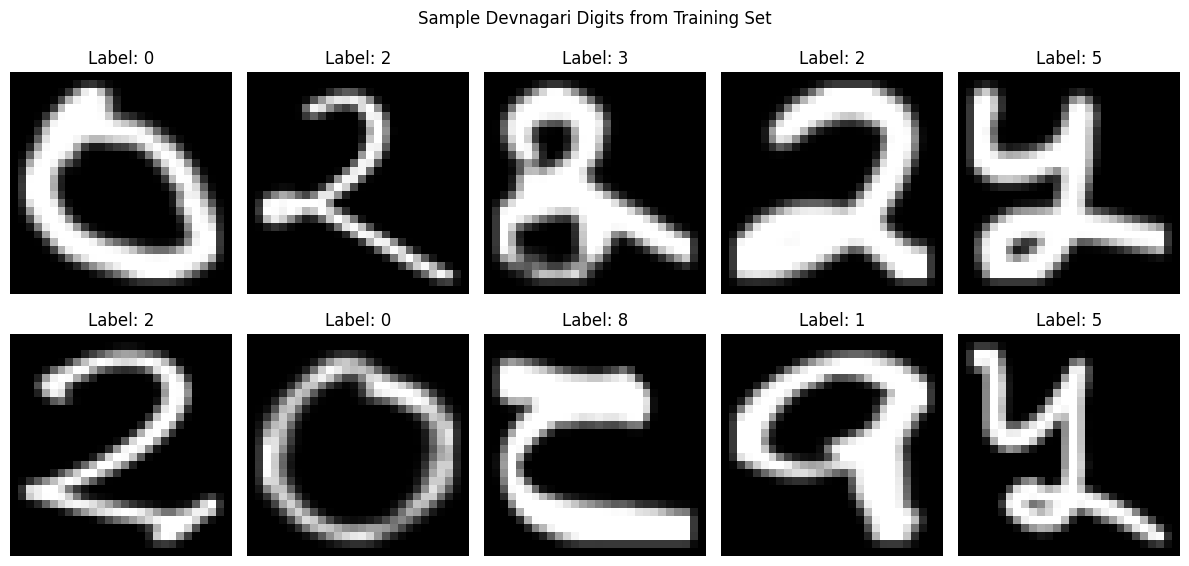

In [13]:
# Visualize sample images
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.suptitle('Sample Devnagari Digits from Training Set')
plt.tight_layout()
plt.show()

In [14]:
# ============================================
# TASK 2: Build the FCN Model
# ============================================

def build_fcn_model(input_shape=(28, 28, 1), num_classes=10):
    """
    Build a Fully Connected Neural Network with:
    - 3 hidden layers with ReLU activation
    - Dropout for regularization
    - Batch Normalization for stability
    """
    model = keras.Sequential([
        # Input layer
        keras.layers.Input(shape=input_shape),

        # Flatten the 2D image to 1D vector
        keras.layers.Flatten(),

        # Hidden Layer 1: 64 neurons with ReLU
        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),

        # Hidden Layer 2: 128 neurons with ReLU
        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),

        # Hidden Layer 3: 256 neurons with ReLU
        keras.layers.Dense(256, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),

        # Output Layer: 10 neurons with softmax
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Build the model
model = build_fcn_model(input_shape=(28, 28, 1), num_classes=num_classes)

print("Model Architecture:")
model.summary()

total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,946 (374.79 KB)

 Trainable params: 95,050 (371.29 KB)

 Non-trainable params: 896 (3.50 KB)


Total parameters: 95,946


In [15]:
# ============================================
# TASK 3: Compile the Model
# ============================================

# Use Adam optimizer with appropriate learning rate
optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"Optimizer: Adam (learning_rate=0.001)")
print(f"Loss function: Categorical Crossentropy")
print(f"Metrics: Accuracy")

Model compiled successfully!
Optimizer: Adam (learning_rate=0.001)
Loss function: Categorical Crossentropy
Metrics: Accuracy


In [16]:
# ============================================
# TASK 4: Train the Model with Validation Data
# ============================================

batch_size = 128
epochs = 30

# Learning rate scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

callbacks = [
    ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    reduce_lr
]

print("Starting training...")
print(f"Batch size: {batch_size}")
print(f"Epochs: {epochs}")
print(f"Training samples: {len(x_train)}")
print(f"Validation samples: {len(x_val)}")
print("-" * 50)

# Train the model with explicit validation data
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_val, y_val),  # Using explicit validation data
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

Starting training...
Batch size: 128
Epochs: 30
Training samples: 13600
Validation samples: 3400
--------------------------------------------------
Epoch 1/30
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5535 - loss: 1.4107
Epoch 1: val_accuracy improved from None to 0.92235, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7193 - loss: 0.8528 - val_accuracy: 0.9224 - val_loss: 0.4236 - learning_rate: 0.0010
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8784 - loss: 0.3601
Epoch 2: val_accuracy improved from 0.92235 to 0.95559, saving model to best_devnagari_model.keras

Epoch 2: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8851 - loss: 0.3387 - val_accuracy: 0.9556 - val_loss: 0.1572 - learning_rate: 0.0010
Epoch 3/30
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9194 - lo

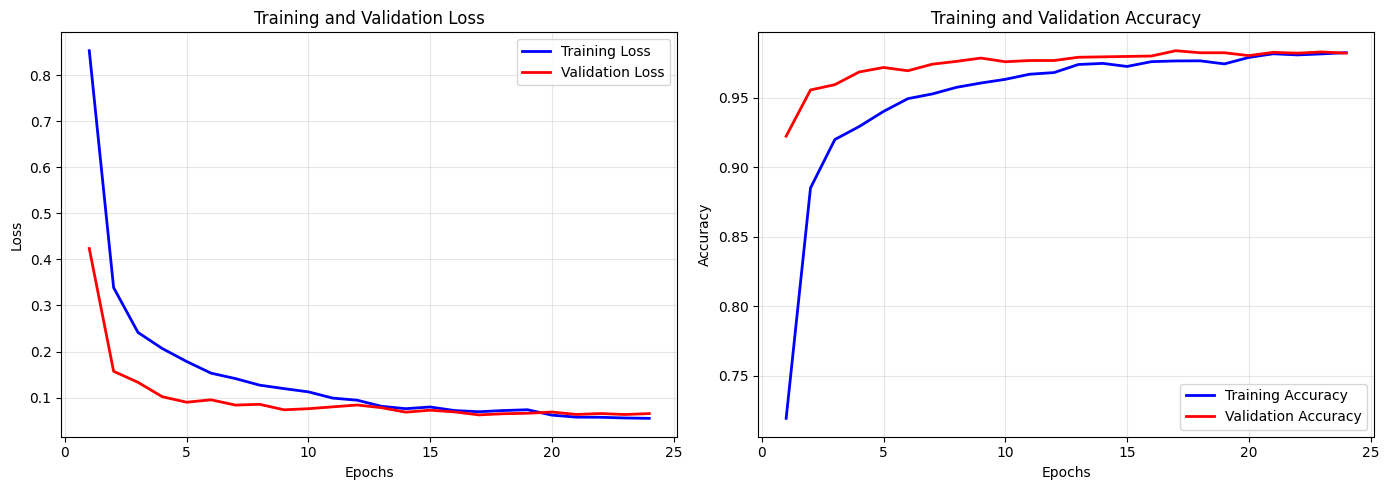


📊 Training Summary:
   Best Validation Accuracy: 0.9838 at Epoch 17
   Best Training Accuracy: 0.9765
   Final Training Accuracy: 0.9824
   Final Validation Accuracy: 0.9821


In [17]:
# ============================================
# Visualize Training Progress
# ============================================

train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
axes[0].plot(range(1, len(train_loss) + 1), train_loss, 'b-', label='Training Loss', linewidth=2)
axes[0].plot(range(1, len(val_loss) + 1), val_loss, 'r-', label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(range(1, len(train_accuracy) + 1), train_accuracy, 'b-', label='Training Accuracy', linewidth=2)
axes[1].plot(range(1, len(val_accuracy) + 1), val_accuracy, 'r-', label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best metrics
best_val_accuracy = max(val_accuracy)
best_epoch = val_accuracy.index(best_val_accuracy) + 1
best_train_accuracy = train_accuracy[best_epoch - 1]

print(f"\nTraining Summary:")
print(f"   Best Validation Accuracy: {best_val_accuracy:.4f} at Epoch {best_epoch}")
print(f"   Best Training Accuracy: {best_train_accuracy:.4f}")
print(f"   Final Training Accuracy: {train_accuracy[-1]:.4f}")
print(f"   Final Validation Accuracy: {val_accuracy[-1]:.4f}")

In [18]:
# ============================================
# TASK 5: Evaluate the Model
# ============================================

print("Evaluating model on test set...")
test_loss, test_accuracy = model.evaluate(x_test, y_test_categorical, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Also evaluate on training and validation sets
train_loss_final, train_accuracy_final = model.evaluate(x_train, y_train, verbose=0)
val_loss_final, val_accuracy_final = model.evaluate(x_val, y_val, verbose=0)

print(f"\nTraining Loss: {train_loss_final:.4f}")
print(f"Training Accuracy: {train_accuracy_final:.4f}")
print(f"Validation Loss: {val_loss_final:.4f}")
print(f"Validation Accuracy: {val_accuracy_final:.4f}")

# Check for overfitting
print("\n--- Overfitting Analysis ---")
if train_accuracy_final - test_accuracy > 0.1:
    print(f"Potential overfitting detected!")
    print(f"   (Train: {train_accuracy_final:.4f}, Test: {test_accuracy:.4f})")
elif test_accuracy < 0.7:
    print(f"Model may need more training!")
    print(f"   (Test accuracy: {test_accuracy:.4f})")
else:
    print(f"✓ Model generalizes well!")
    print(f"   (Train: {train_accuracy_final:.4f}, Test: {test_accuracy:.4f})")

Evaluating model on test set...
Test Loss: 0.0635
Test Accuracy: 0.9833

Training Loss: 0.0132
Training Accuracy: 0.9960
Validation Loss: 0.0626
Validation Accuracy: 0.9838

--- Overfitting Analysis ---
✓ Model generalizes well!
   (Train: 0.9960, Test: 0.9833)


In [19]:
# ============================================
# TASK 6: Save and Load the Model
# ============================================

# Save the trained model
model.save('devnagari_fcn_model.h5')
print("Model saved as 'devnagari_fcn_model.h5'")

# Load the saved model
print("\nLoading saved model...")
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded successfully!")

# Verify loaded model
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(x_test, y_test_categorical, verbose=0)
print(f"\nLoaded Model - Test Loss: {loaded_test_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_test_accuracy:.4f}")

if abs(loaded_test_accuracy - test_accuracy) < 0.001:
    print("Loaded model matches original model performance!")
else:
    print("Warning: Loaded model performance differs from original!")

Model saved as 'devnagari_fcn_model.h5'

Loading saved model...
Model loaded successfully!

Loaded Model - Test Loss: 0.0635
Loaded Model - Test Accuracy: 0.9833
✓ Loaded model matches original model performance!


In [20]:
# ============================================
# TASK 7: Make Predictions
# ============================================

print("Making predictions on test images...")
predictions = loaded_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = y_test

# Display first 30 predictions
print("\nFirst 30 predictions (Predicted vs Actual):")
print("-" * 45)
correct_first_30 = 0
for i in range(30):
    status = "✓" if predicted_labels[i] == true_labels[i] else "✗"
    print(f"Image {i+1:2d}: Predicted = {predicted_labels[i]}, Actual = {true_labels[i]} {status}")
    if predicted_labels[i] == true_labels[i]:
        correct_first_30 += 1

print(f"\nFirst 30 Accuracy: {correct_first_30}/30 = {correct_first_30/30:.2%}")

# Calculate overall accuracy
correct_predictions = np.sum(predicted_labels == true_labels)
total_predictions = len(true_labels)
accuracy = correct_predictions / total_predictions
print(f"\nOverall Test Accuracy: {accuracy:.4f} ({correct_predictions}/{total_predictions})")

Making predictions on test images...

First 30 predictions (Predicted vs Actual):
---------------------------------------------
Image  1: Predicted = 0, Actual = 0 ✓
Image  2: Predicted = 0, Actual = 0 ✓
Image  3: Predicted = 0, Actual = 0 ✓
Image  4: Predicted = 0, Actual = 0 ✓
Image  5: Predicted = 0, Actual = 0 ✓
Image  6: Predicted = 0, Actual = 0 ✓
Image  7: Predicted = 0, Actual = 0 ✓
Image  8: Predicted = 0, Actual = 0 ✓
Image  9: Predicted = 0, Actual = 0 ✓
Image 10: Predicted = 0, Actual = 0 ✓
Image 11: Predicted = 0, Actual = 0 ✓
Image 12: Predicted = 0, Actual = 0 ✓
Image 13: Predicted = 0, Actual = 0 ✓
Image 14: Predicted = 0, Actual = 0 ✓
Image 15: Predicted = 0, Actual = 0 ✓
Image 16: Predicted = 0, Actual = 0 ✓
Image 17: Predicted = 0, Actual = 0 ✓
Image 18: Predicted = 0, Actual = 0 ✓
Image 19: Predicted = 0, Actual = 0 ✓
Image 20: Predicted = 0, Actual = 0 ✓
Image 21: Predicted = 0, Actual = 0 ✓
Image 22: Predicted = 0, Actual = 0 ✓
Image 23: Predicted = 0, Actual = 0 

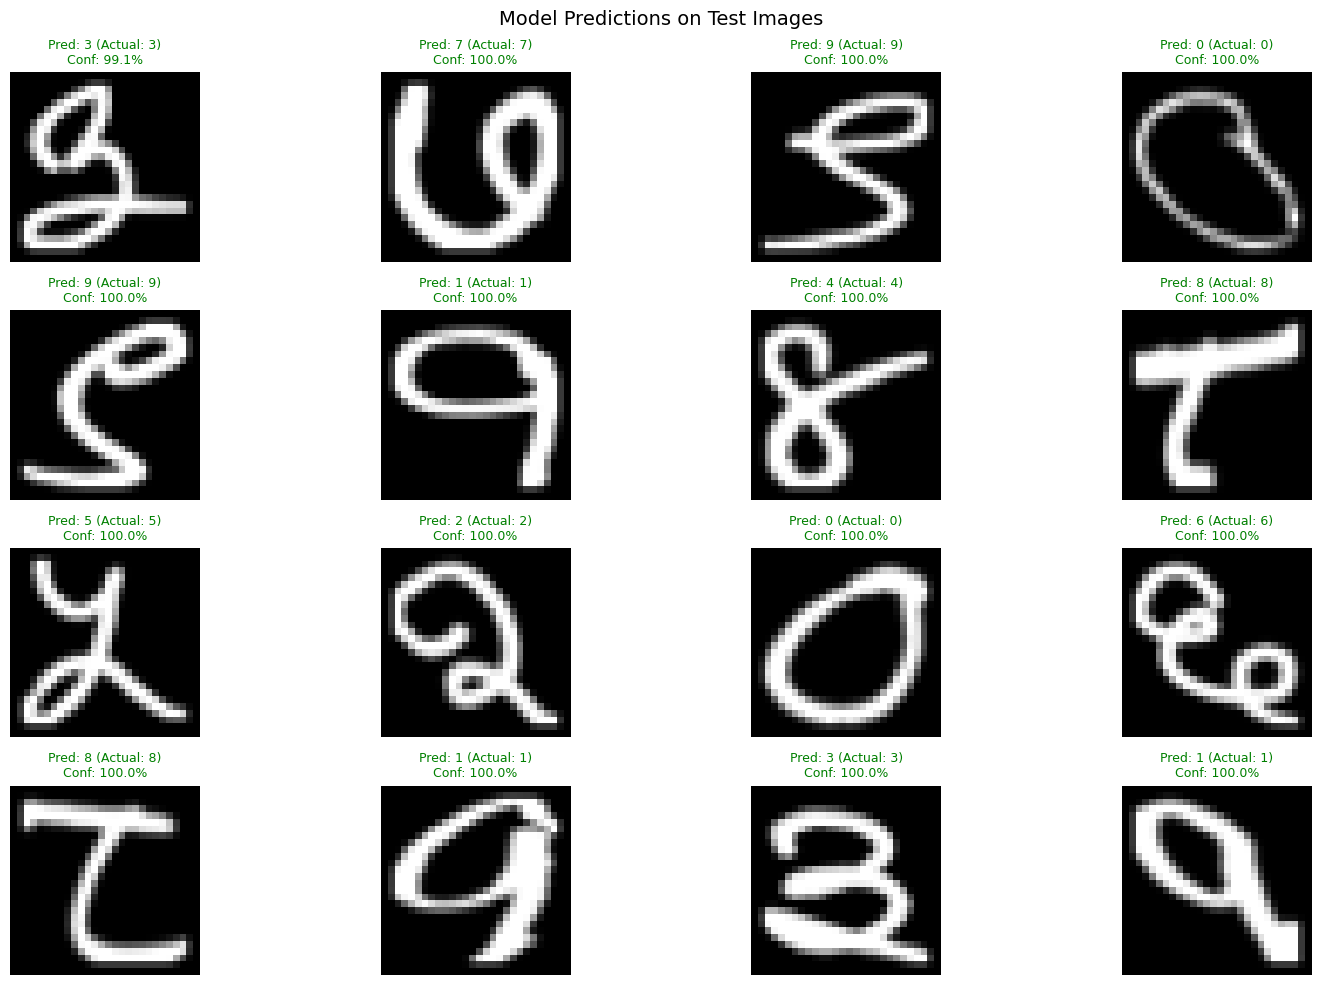

In [21]:
# Visualize predictions with correct/incorrect labels
num_samples = 16
random_indices = np.random.choice(len(x_test), num_samples, replace=False)

plt.figure(figsize=(16, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')

    pred = predicted_labels[idx]
    actual = true_labels[idx]
    color = 'green' if pred == actual else 'red'

    confidence = np.max(predictions[idx]) * 100
    plt.title(f'Pred: {pred} (Actual: {actual})\nConf: {confidence:.1f}%',
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('Model Predictions on Test Images', fontsize=14)
plt.tight_layout()
plt.show()

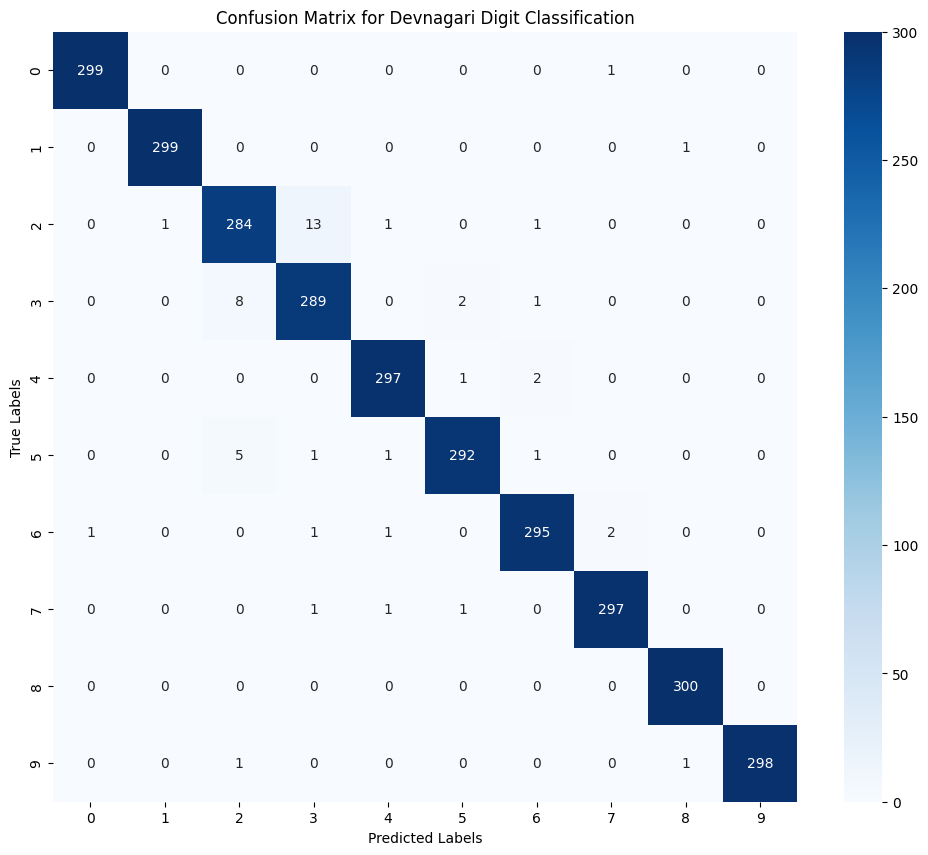


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       1.00      1.00      1.00       300
           2       0.95      0.95      0.95       300
           3       0.95      0.96      0.96       300
           4       0.99      0.99      0.99       300
           5       0.99      0.97      0.98       300
           6       0.98      0.98      0.98       300
           7       0.99      0.99      0.99       300
           8       0.99      1.00      1.00       300
           9       1.00      0.99      1.00       300

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



In [22]:
# ============================================
# Confusion Matrix
# ============================================

try:
    from sklearn.metrics import confusion_matrix, classification_report
    import seaborn as sns

    # Generate confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(num_classes),
                yticklabels=range(num_classes))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix for Devnagari Digit Classification')
    plt.show()

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(true_labels, predicted_labels))

except ImportError:
    print("Seaborn not installed. Installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'seaborn', '-q'])
    print("Please rerun this cell after installation")